In [4]:
import pandas as pd
import numpy as np

# 1. Montando o Google Drive (Vai pedir permissão na hora)
from google.colab import drive
drive.mount('/content/drive')

# 2. Carregando o arquivo (Ajuste o caminho se necessário!)
# Dica: No menu esquerdo do Colab (ícone de pasta), navegue até o arquivo,
# clique com botão direito e escolha "Copiar caminho".
caminho_do_arquivo = '/content/drive/MyDrive/ABTest/ab_test.csv'
df = pd.read_csv(caminho_do_arquivo)

# 3. Inspeção Inicial
print(f"Total de linhas originais: {df.shape[0]}")
print("-" * 30)

# 4. Verificando o "Mismatch" (O erro clássico deste dataset)
# Usuários do grupo 'treatment' DEVEM ver a 'new_page'.
# Usuários do grupo 'control' DEVEM ver a 'old_page'.
# Vamos contar quantas vezes isso NÃO aconteceu.
mismatch = df[((df['con_treat'] == 'treatment') == (df['page'] == 'new_page')) == False]
print(f"Linhas com erro de alinhamento (Mismatch): {len(mismatch)}")

# 5. Limpeza: Criando um novo dataframe apenas com os dados corretos
df2 = df[((df['con_treat'] == 'treatment') == (df['page'] == 'new_page')) == True]

print("-" * 30)
print(f"Total de linhas após limpeza: {df2.shape[0]}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total de linhas originais: 294478
------------------------------
Linhas com erro de alinhamento (Mismatch): 3893
------------------------------
Total de linhas após limpeza: 290585


In [5]:
# 1. Verificando se há usuários repetidos
usuarios_duplicados = df2[df2.duplicated(['id'], keep=False)]

print(f"Quantidade de registros duplicados: {len(usuarios_duplicados)}")

# Se houver duplicatas, vamos dar uma olhada nelas
if len(usuarios_duplicados) > 0:
    display(usuarios_duplicados.head())

# 2. Removendo as duplicatas (Mantendo apenas a primeira aparição)
# Isso garante que cada id seja único no dataset final
df2 = df2.drop_duplicates(subset=['id'], keep='first')

print("-" * 30)
print(f"Linhas finais após remover duplicatas: {df2.shape[0]}")

# 3. Probabilidades Iniciais (O "Placar do Jogo" antes do juiz apitar)
# Vamos ver a taxa de conversão bruta de cada grupo
taxa_geral = df2['converted'].mean()
taxa_controle = df2[df2['con_treat'] == 'control']['converted'].mean()
taxa_tratamento = df2[df2['con_treat'] == 'treatment']['converted'].mean()

print("-" * 30)
print(f"Taxa de Conversão Geral: {taxa_geral:.4%}")
print(f"Taxa Conversão Controle (A): {taxa_controle:.4%}")
print(f"Taxa Conversão Tratamento (B): {taxa_tratamento:.4%}")

Quantidade de registros duplicados: 2


,id,time,con_treat,page,converted
1899,773192,37:58.8,treatment,new_page,0
2893,773192,55:59.6,treatment,new_page,0


------------------------------
Linhas finais após remover duplicatas: 290584
------------------------------
Taxa de Conversão Geral: 11.9597%
Taxa Conversão Controle (A): 12.0386%
Taxa Conversão Tratamento (B): 11.8808%


In [6]:
import statsmodels.api as sm

# 1. Preparando os dados para o teste
# Precisamos do número de sucessos (conversões) e do total de observações para cada grupo
n_convertidos_control = df2[df2['con_treat'] == 'control']['converted'].sum()
n_convertidos_treatment = df2[df2['con_treat'] == 'treatment']['converted'].sum()

n_obs_control = df2[df2['con_treat'] == 'control']['id'].count()
n_obs_treatment = df2[df2['con_treat'] == 'treatment']['id'].count()

# 2. Rodando o Z-Test
# alternative='larger' significa que nossa hipótese H1 é: Treatment > Control
z_score, p_valor = sm.stats.proportions_ztest([n_convertidos_treatment, n_convertidos_control],
                                              [n_obs_treatment, n_obs_control],
                                              alternative='larger')

print(f"Z-Score: {z_score:.4f}")
print(f"P-Valor: {p_valor:.4f}")

# 3. Interpretando automaticamente
alpha = 0.05
if p_valor < alpha:
    print("\nCONCLUSÃO: Rejeitamos H0. A nova página é estatisticamente MELHOR.")
else:
    print("\nCONCLUSÃO: Falhamos em rejeitar H0. Não há evidências de que a nova página seja melhor.")

Z-Score: -1.3109
P-Valor: 0.9051

CONCLUSÃO: Falhamos em rejeitar H0. Não há evidências de que a nova página seja melhor.


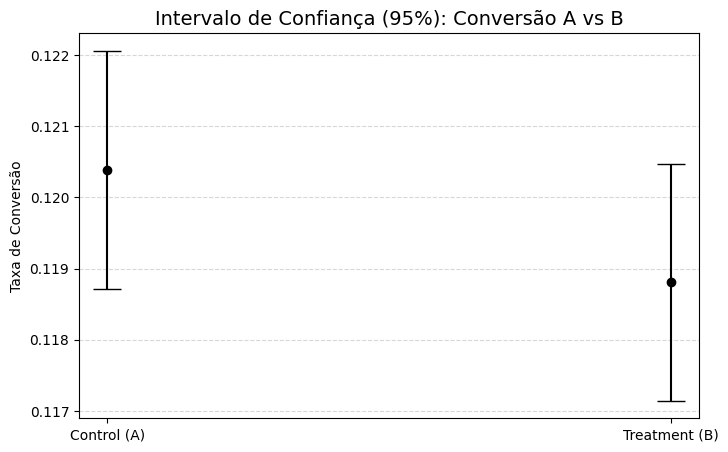

IC 95% Controle:   [0.1187, 0.1221]
IC 95% Tratamento: [0.1171, 0.1205]


In [7]:
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportion_confint

# 1. Calculando os Intervalos de Confiança (95%)
lower_con, upper_con = proportion_confint(n_convertidos_control, n_obs_control, alpha=0.05)
lower_treat, upper_treat = proportion_confint(n_convertidos_treatment, n_obs_treatment, alpha=0.05)

# 2. Preparando o Gráfico
plt.figure(figsize=(8, 5))
plt.errorbar(x=['Control (A)', 'Treatment (B)'],
             y=[taxa_controle, taxa_tratamento],
             yerr=[(upper_con-lower_con)/2, (upper_treat-lower_treat)/2],
             fmt='o', color='black', capsize=10, label='Média ± IC 95%')

plt.title('Intervalo de Confiança (95%): Conversão A vs B', fontsize=14)
plt.ylabel('Taxa de Conversão')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)

# 3. Mostrando o gráfico
# Se as barras de erro se sobrepõem muito ou se B está abaixo de A, confirmamos a decisão.
plt.show()

print(f"IC 95% Controle:   [{lower_con:.4f}, {upper_con:.4f}]")
print(f"IC 95% Tratamento: [{lower_treat:.4f}, {upper_treat:.4f}]")

# 4. Conclusão e Recomendação Estratégica

## Resultado Estatístico
O teste A/B realizado resultou num **P-Valor de 0.9051**.
Considerando um nível de significância ($\alpha$) de 0.05, **falhamos em rejeitar a Hipótese Nula**.

Estatisticamente, não há evidências para afirmar que a Nova Página (B) gera mais conversões do que a Antiga (A). Pelo contrário, os dados observados mostram uma leve desvantagem para a nova versão.

## Recomendação de Negócio 🚀
Com base nos dados, a recomendação para a diretoria é:
1.  **NÃO implementar a nova página.**
2.  **Manter a página atual (Controle)**, pois ela performa igual ou melhor que a nova versão.
3.  **Investigar:** A equipa de UX deve rever o design da nova página, pois a mudança proposta não gerou o impacto esperado nos utilizadores.

**Impacto:** Esta análise evitou a implementação de uma funcionalidade ineficiente, poupando custos de desenvolvimento e prevenindo uma potencial queda nas vendas.